<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/11-LinearRegression_and_assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression
It is implemented in two ways:


1.   OLS → Ordinary Least Squares *(Formula based)* **(Small Data)**
2.   Gradient Descent *(Descent based, finds the fit slowly)* **(Big Data)**



OLS formula is determined using fundamentals of calculus, we just find the minima of Sum of Squared Residuals/Errors (SSR/E)



```
Used by Scikit Learn LOgistic Regression Library
```



For simple linear regression it is very simple and straight forward, but for multiple linear regression, it uses matrix differentiation and then the formula is evaluated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [30]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

## Assumptions:


### 1. Linear Relationship:
The relation of every input column with output should be sort of linear.

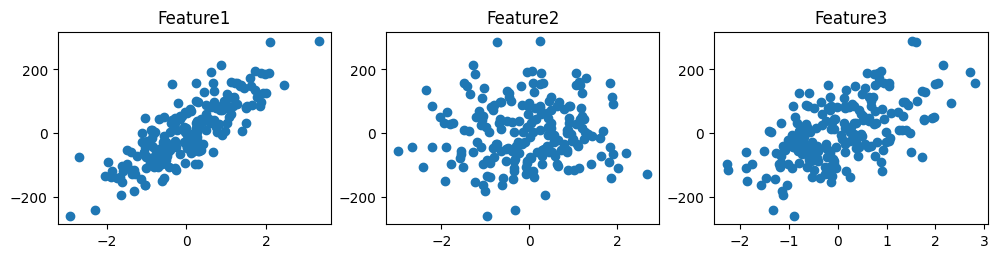

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

All of them have a sort of linear relationship with the output.

### 2. Multicollinearity
Each and every column in the data should be independent of all the other columns. There should not be any collinearity between columns for linear regression to work effectively.
As we will never be able to know which feature is more dominant/relevant.

This can be checked through code itself.

In [18]:
# Using VIF (Variant inflation factor) method

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [26]:
pd.DataFrame({'vif': vif}, index = df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


All the VIFs are around 1(one), therefore there is no multicollinearity between columns. But if any of these were to be 5 or more than that, it would mean that there exists some multicollinearity.

If the later was to be the case, we would need to remove the column which is dependent as other columns would be able to do the work it is performing.

<Axes: >

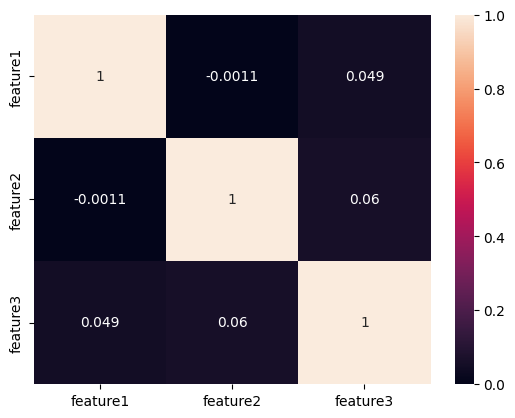

In [33]:
# Another Technique

sns.heatmap(df.iloc[:,0:3].corr(), annot =True)

### 3. Normal Residual
The distribution plot of residual/error should be normal.

Either check it by QQPlot or KDEPlot

<Axes: ylabel='Density'>

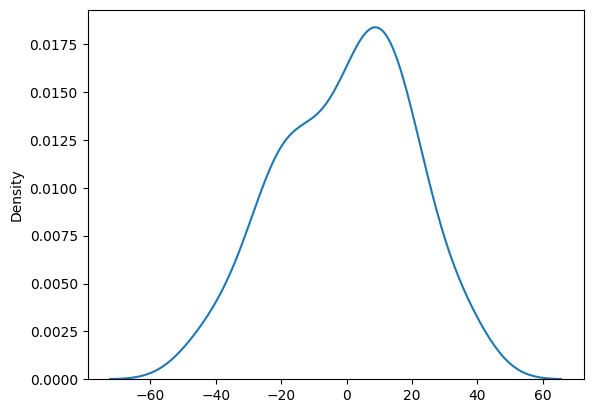

In [34]:
sns.kdeplot(residual)

Apart from a little bump, it is pretty much a normally ditributed data.

In [35]:
from scipy import stats

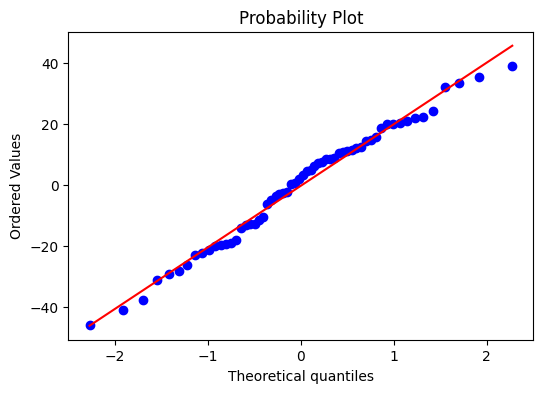

In [47]:
fig, ax = plt.subplots(figsize=(6,4))
stats.probplot(residual, plot=ax, fit=True)

plt.show()

### 4. Homoscedasticity
The plot of y_pred vs residual should be scaterred uniformly and not have some kind of converging or diverging pattern.

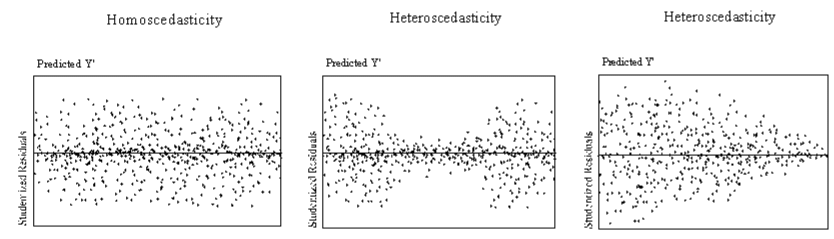

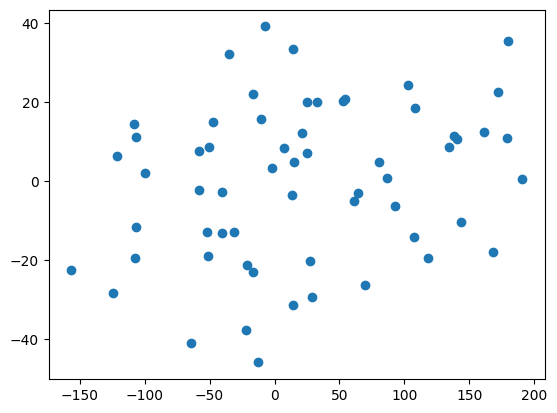

In [40]:
plt.scatter(y_pred, residual)

No specific wormhole or funnel pattern can be seen, so we can safely say that this assumption holds true.

### 5. No Autocorrelation of Error
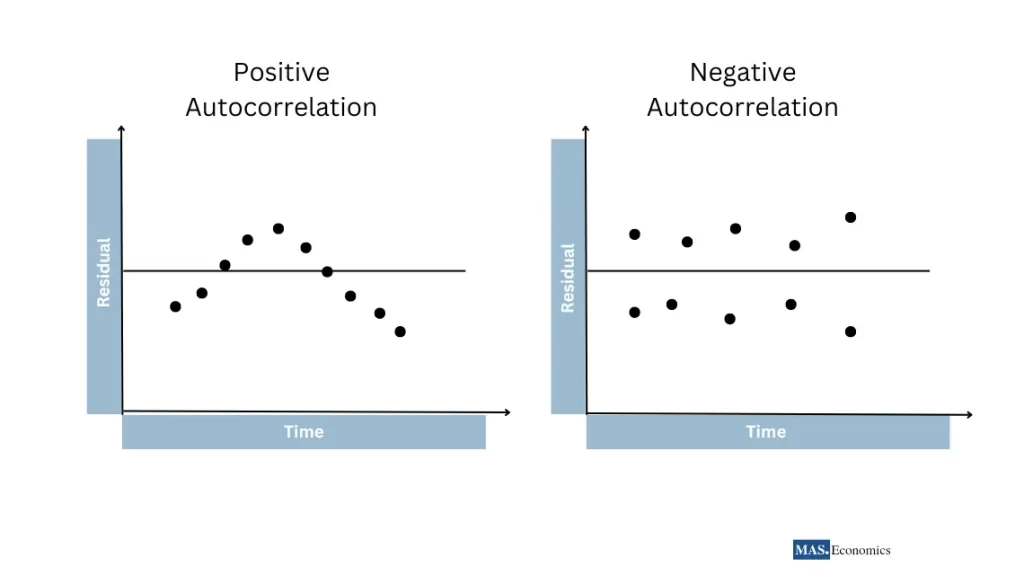

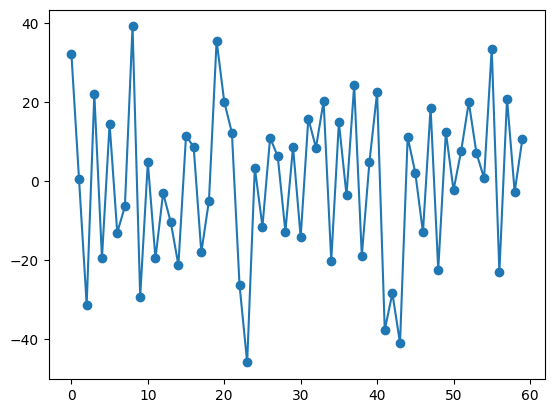

In [49]:
plt.scatter(range(len(residual)), residual)
plt.plot(residual)
plt.show()

we can say that this assumption also holds true as there is no correlation to be seen in the above plot.